# 1. Setup

1. Setup

In [ ]:
# ── Quick Reconnect Setup ──────────────────────────
import os, subprocess

# 1. Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Remove peft if leftover from previous session
result = subprocess.run(['pip', 'show', 'peft'], capture_output=True, text=True)
if 'peft' in result.stdout:
    os.system('pip uninstall -q -y peft')
    print("✅ Removed leftover peft")

# 3. Clone SparseGPT
os.system('cd /content && rm -rf sparsegpt && git clone https://github.com/IST-DASLab/sparsegpt.git')

# 4. Install packages
os.system('pip install -q transformers==4.37.2 accelerate==0.30.0 datasets==2.16.1 sentencepiece safetensors')

# 5. Fix accelerate compatibility
import torch, gc
import accelerate.utils.memory as mem
if not hasattr(mem, 'clear_device_cache'):
    def clear_device_cache():
        gc.collect()
        torch.cuda.empty_cache()
    mem.clear_device_cache = clear_device_cache
print("✅ accelerate patch applied!")

# 6. HF Login
from google.colab import userdata
from huggingface_hub import login
login(userdata.get('HF_TOKEN'))

print("✅ All setup done — ready to go!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Removed leftover peft
✅ accelerate patch applied!
✅ All setup done — ready to go!


# 2. Prune Llama with SparseGPT - Full Sweep fp16

2. Prune LlaMA2 with SparseGPT - Full Sweep

In [ ]:
import subprocess
import os

log_dir = '/content/drive/MyDrive/sparsegpt_results'
os.makedirs(log_dir, exist_ok=True)
sparsity_levels = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

for sparsity in sparsity_levels:
    s_int = int(sparsity * 100)
    save_dir = f'{log_dir}/sparse{s_int}/checkpoints'
    log_file = f'{log_dir}/log_sparse{s_int}.txt'
    os.makedirs(save_dir, exist_ok=True)

    # Smart skip
    if os.path.exists(log_file):
        with open(log_file, 'r') as f:
            content = f.read()
        if 'Perplexity:' in content:
            print(f"⏭️ sparse{s_int}% already done — skipping")
            continue
        else:
            print(f"⚠️ Log exists but incomplete — re-running {s_int}%")

    print(f"\n{'='*50}")
    print(f"  🔄 Pruning at {s_int}% sparsity...")
    print(f"{'='*50}")

    cmd = [
        'python', '/content/sparsegpt/llama.py',
        'meta-llama/Llama-2-7b-hf', 'wikitext2',
        '--nsamples', '128',
        '--sparsity', str(sparsity),
        '--save', save_dir
    ]

    with open(log_file, 'w') as log:
        process = subprocess.Popen(cmd, stdout=subprocess.PIPE,
                                   stderr=subprocess.STDOUT, text=True)
        for line in process.stdout:
            print(line, end='')
            log.write(line)
        process.wait()

    if process.returncode != 0:
        print(f"❌ {s_int}% FAILED!")
    else:
        print(f"✅ {s_int}% done!")

print("\n🎉 All sparsity levels complete!")

⏭️ sparse0% already done — skipping
⏭️ sparse10% already done — skipping
⏭️ sparse20% already done — skipping
⏭️ sparse30% already done — skipping
⏭️ sparse40% already done — skipping
⏭️ sparse50% already done — skipping
⏭️ sparse60% already done — skipping
⏭️ sparse70% already done — skipping

🎉 All sparsity levels complete!


# 3. Sparse + Quantized

3. Sparse + Quantized

In [ ]:
import subprocess
import os

log_dir = '/content/drive/MyDrive/sparsegpt_results'

experiments = [
    {'sparsity': 0.0, 'wbits': 4, 'label': 'dense_int4'},
    {'sparsity': 0.5, 'wbits': 4, 'label': 'sparse50_int4'},
    {'sparsity': 0.7, 'wbits': 4, 'label': 'sparse70_int4'},
]

for exp in experiments:
    sparsity = exp['sparsity']
    wbits    = exp['wbits']
    label    = exp['label']
    save_dir = f'{log_dir}/{label}/checkpoints'
    log_file = f'{log_dir}/log_{label}.txt'
    os.makedirs(save_dir, exist_ok=True)

    if os.path.exists(log_file):
        with open(log_file, 'r') as f:
            content = f.read()
        if 'Perplexity:' in content:
            print(f"⏭️ {label} already done — skipping")
            continue

    print(f"\n{'='*50}")
    print(f"  🔄 Running: sparsity={int(sparsity*100)}% + {wbits}-bit")
    print(f"{'='*50}")

    cmd = [
        'python', '/content/sparsegpt/llama.py',
        'meta-llama/Llama-2-7b-hf', 'wikitext2',
        '--nsamples', '128',
        '--sparsity', str(sparsity),
        '--wbits', str(wbits),
        '--save', save_dir
    ]

    with open(log_file, 'w') as log:
        process = subprocess.Popen(cmd, stdout=subprocess.PIPE,
                                   stderr=subprocess.STDOUT, text=True)
        for line in process.stdout:
            print(line, end='')
            log.write(line)
        process.wait()

    if process.returncode != 0:
        print(f"❌ {label} FAILED!")
    else:
        print(f"✅ {label} done!")

print("\n🎉 All sparse+quantized experiments complete!")

⏭️ dense_int4 already done — skipping
⏭️ sparse50_int4 already done — skipping
⏭️ sparse70_int4 already done — skipping

🎉 All sparse+quantized experiments complete!


# 4. Extract and Plot Perplexity

4. Extract and Plot Perplexity

✅ 0% → Perplexity: 5.47
✅ 10% → Perplexity: 5.49
✅ 20% → Perplexity: 5.58
✅ 30% → Perplexity: 5.71
✅ 40% → Perplexity: 5.94
✅ 50% → Perplexity: 6.50
✅ 60% → Perplexity: 8.37
✅ 70% → Perplexity: 17.12


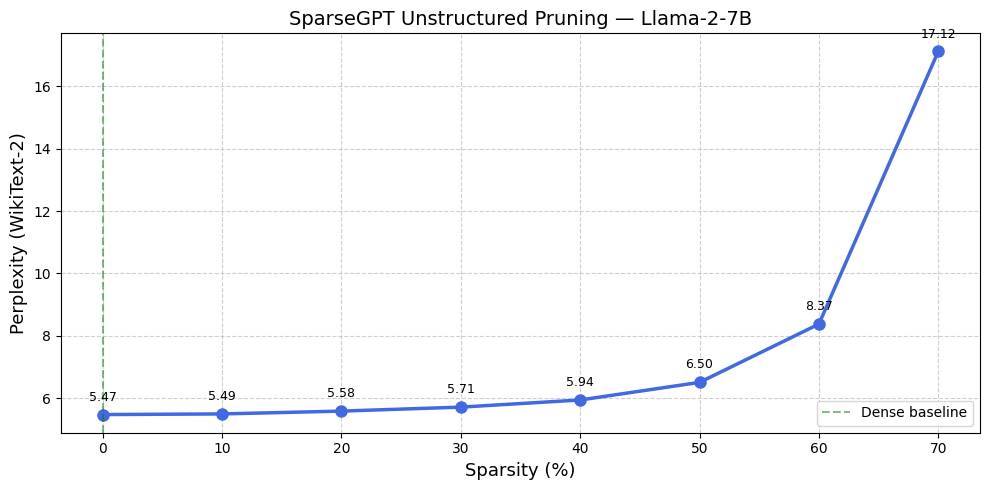

✅ Plot saved!


In [ ]:
import os
import matplotlib.pyplot as plt

log_dir = '/content/drive/MyDrive/sparsegpt_results'
sparsity_levels = [0, 10, 20, 30, 40, 50, 60, 70]
sparsities, perplexities = [], []

for s in sparsity_levels:
    log_path = f'{log_dir}/log_sparse{s}.txt'
    if not os.path.exists(log_path):
        print(f"⚠️ Missing log for {s}%")
        continue
    with open(log_path, 'r') as f:
        for line in f.readlines():
            if line.startswith('Perplexity:'):
                ppl = float(line.strip().split(': ')[1])
                sparsities.append(s)
                perplexities.append(ppl)
                print(f"✅ {s}% → Perplexity: {ppl:.2f}")
                break

plt.figure(figsize=(10, 5))
plt.plot(sparsities, perplexities, marker='o', linewidth=2.5,
         markersize=8, color='royalblue')
for x, y in zip(sparsities, perplexities):
    plt.annotate(f'{y:.2f}', (x, y), textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=9)
plt.axvline(x=0, color='green', linestyle='--', alpha=0.5, label='Dense baseline')
plt.xlabel('Sparsity (%)', fontsize=13)
plt.ylabel('Perplexity (WikiText-2)', fontsize=13)
plt.title('SparseGPT Unstructured Pruning — Llama-2-7B', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(f'{log_dir}/sparsity_vs_perplexity.png', dpi=150)
plt.show()
print("✅ Plot saved!")

# 5. Pruning vs Quantization Plot

5. Pruning vs Quantization Plot

✅ log_dense_int4.txt → 5.47
✅ log_sparse50_int4.txt → 6.97
✅ log_sparse70_int4.txt → 20.70


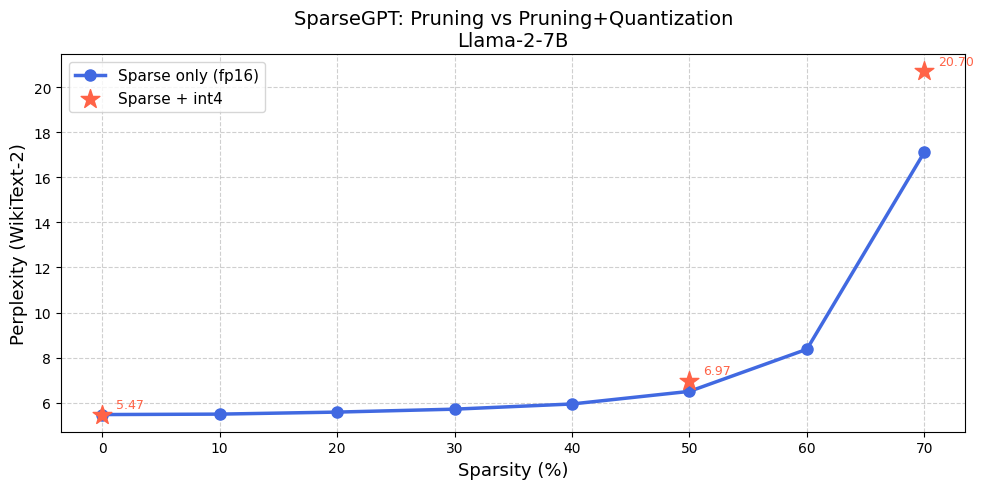

✅ Comparison plot saved!


In [ ]:
import os
import matplotlib.pyplot as plt

log_dir = '/content/drive/MyDrive/sparsegpt_results'

fp16_data = {0: 5.47, 10: 5.49, 20: 5.58, 30: 5.71,
             40: 5.94, 50: 6.50, 60: 8.37, 70: 17.12}

quant_data = {}
quant_logs = {0: 'log_dense_int4.txt', 50: 'log_sparse50_int4.txt',
              70: 'log_sparse70_int4.txt'}

for s, logfile in quant_logs.items():
    path = f'{log_dir}/{logfile}'
    if not os.path.exists(path):
        print(f"⚠️ Missing {logfile}")
        continue
    with open(path, 'r') as f:
        for line in f.readlines():
            if line.startswith('Perplexity:'):
                quant_data[s] = float(line.strip().split(': ')[1])
                print(f"✅ {logfile} → {quant_data[s]:.2f}")
                break

plt.figure(figsize=(10, 5))
plt.plot(list(fp16_data.keys()), list(fp16_data.values()),
         marker='o', linewidth=2.5, markersize=8,
         color='royalblue', label='Sparse only (fp16)')
if quant_data:
    plt.scatter(list(quant_data.keys()), list(quant_data.values()),
                marker='*', s=200, color='tomato', zorder=5, label='Sparse + int4')
    for x, y in quant_data.items():
        plt.annotate(f'{y:.2f}', (x, y), textcoords="offset points",
                    xytext=(10, 5), fontsize=9, color='tomato')
plt.xlabel('Sparsity (%)', fontsize=13)
plt.ylabel('Perplexity (WikiText-2)', fontsize=13)
plt.title('SparseGPT: Pruning vs Pruning+Quantization\nLlama-2-7B', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{log_dir}/pruning_vs_quantization.png', dpi=150)
plt.show()
print("✅ Comparison plot saved!")

# 6. Zero-Shot Evaluation

6. Zero-shot Evaluation

In [ ]:
# ⚠️ NOTE FOR REPRODUCIBILITY:
# After this cell finishes, you MUST:
# 1. Runtime → Restart Runtime
# 2. Re-run Cell 1
# 3. Then continue with Cell 7 onwards

import os, subprocess

# Install peft + lm-eval for this cell only
os.system('pip install -q lm-eval==0.4.2 peft==0.9.0')

import accelerate.utils.memory as mem
import torch, gc
if not hasattr(mem, 'clear_device_cache'):
    def clear_device_cache():
        gc.collect()
        torch.cuda.empty_cache()
    mem.clear_device_cache = clear_device_cache
try:
    import peft.utils.loftq_utils as loftq
    loftq.clear_device_cache = mem.clear_device_cache
except:
    pass
print("✅ peft + lm-eval ready!\n")

log_dir = '/content/drive/MyDrive/sparsegpt_results'
tasks = "hellaswag,winogrande,piqa,arc_easy,arc_challenge"

fp16_experiments = [
    {'checkpoint': f'{log_dir}/sparse{s}/checkpoints',
     'result_file': f'{log_dir}/zeroshot_sparse{s}.json',
     'label': f'sparse{s}_fp16'}
    for s in [0, 10, 20, 30, 40, 50, 60, 70]
]
quant_experiments = [
    {'checkpoint': f'{log_dir}/dense_int4/checkpoints',
     'result_file': f'{log_dir}/zeroshot_dense_int4.json',
     'label': 'dense_int4'},
    {'checkpoint': f'{log_dir}/sparse50_int4/checkpoints',
     'result_file': f'{log_dir}/zeroshot_sparse50_int4.json',
     'label': 'sparse50_int4'},
    {'checkpoint': f'{log_dir}/sparse70_int4/checkpoints',
     'result_file': f'{log_dir}/zeroshot_sparse70_int4.json',
     'label': 'sparse70_int4'},
]

for exp in fp16_experiments + quant_experiments:
    checkpoint  = exp['checkpoint']
    result_file = exp['result_file']
    label       = exp['label']

    if not os.path.exists(checkpoint):
        print(f"⚠️ No checkpoint for {label} — skipping")
        continue
    if os.path.exists(result_file):
        print(f"⏭️ {label} already evaluated — skipping")
        continue

    print(f"\n{'='*50}")
    print(f"  🔄 Zero-shot eval: {label}")
    print(f"{'='*50}")

    cmd = ['python', '-m', 'lm_eval', '--model', 'hf',
           '--model_args', f'pretrained={checkpoint},tokenizer=meta-llama/Llama-2-7b-hf,dtype=float16',
           '--tasks', tasks, '--num_fewshot', '0',
           '--batch_size', '8', '--output_path', result_file, '--device', 'cuda']

    process = subprocess.Popen(cmd, stdout=subprocess.PIPE,
                               stderr=subprocess.STDOUT, text=True)
    for line in process.stdout:
        print(line, end='')
    process.wait()

    if process.returncode != 0:
        print(f"❌ {label} FAILED!")
    elif os.path.exists(result_file):
        print(f"✅ {label} done!")
    else:
        print(f"❌ {label} — no output file!")

print("\n🎉 All zero-shot evaluations complete!")
print("\n⚠️ RESTART RUNTIME NOW before running Cell 7!")
print("   Runtime → Restart Runtime → Re-run Cell 1 → Continue from Cell 7")

✅ peft + lm-eval ready!

⏭️ sparse0_fp16 already evaluated — skipping
⏭️ sparse10_fp16 already evaluated — skipping
⏭️ sparse20_fp16 already evaluated — skipping
⏭️ sparse30_fp16 already evaluated — skipping
⏭️ sparse40_fp16 already evaluated — skipping
⏭️ sparse50_fp16 already evaluated — skipping
⏭️ sparse60_fp16 already evaluated — skipping
⏭️ sparse70_fp16 already evaluated — skipping
⏭️ dense_int4 already evaluated — skipping
⏭️ sparse50_int4 already evaluated — skipping
⏭️ sparse70_int4 already evaluated — skipping

🎉 All zero-shot evaluations complete!

⚠️ RESTART RUNTIME NOW before running Cell 7!
   Runtime → Restart Runtime → Re-run Cell 1 → Continue from Cell 7


# 7. Zero-Shot Plot (fp16 vs int4)

7. Plot Zero Shot

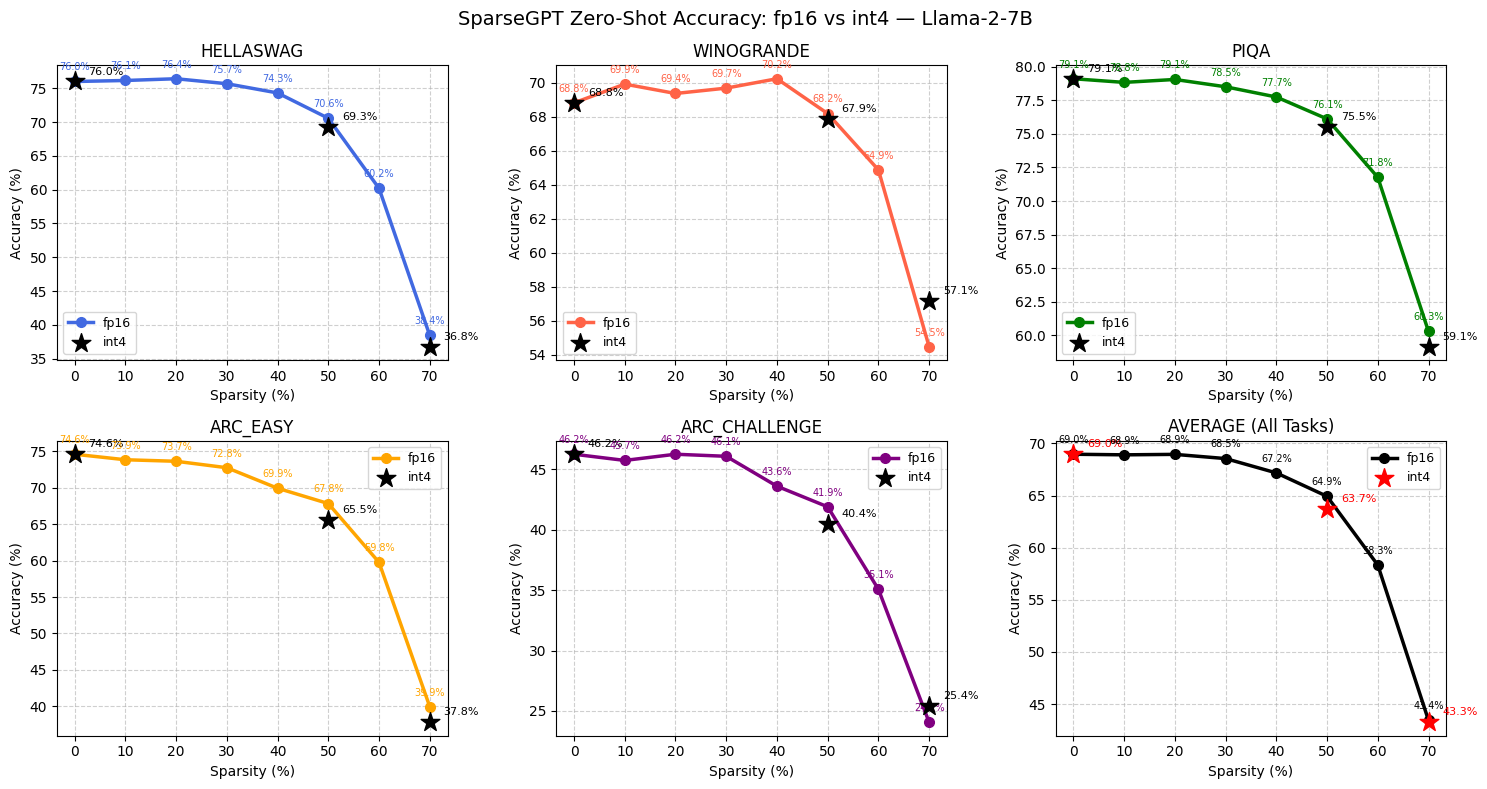

✅ Zero-shot plot saved!


In [ ]:
# ⚠️ Run Cell 1 first after restarting runtime!
import os, json
import matplotlib.pyplot as plt
import numpy as np

log_dir = '/content/drive/MyDrive/sparsegpt_results'
sparsity_levels = [0, 10, 20, 30, 40, 50, 60, 70]
tasks = ['hellaswag', 'winogrande', 'piqa', 'arc_easy', 'arc_challenge']

fp16_results = {task: [] for task in tasks}
fp16_sparsities = []
for s in sparsity_levels:
    result_file = f'{log_dir}/zeroshot_sparse{s}.json'
    if not os.path.exists(result_file):
        continue
    with open(result_file, 'r') as f:
        data = json.load(f)
    fp16_sparsities.append(s)
    for task in tasks:
        task_data = data['results'][task]
        acc = task_data.get('acc_norm,none', task_data.get('acc,none', 0)) * 100
        fp16_results[task].append(acc)

int4_experiments = {0: 'zeroshot_dense_int4.json',
                    50: 'zeroshot_sparse50_int4.json',
                    70: 'zeroshot_sparse70_int4.json'}
int4_results = {task: [] for task in tasks}
int4_sparsities = []
for s, filename in int4_experiments.items():
    result_file = f'{log_dir}/{filename}'
    if not os.path.exists(result_file):
        continue
    with open(result_file, 'r') as f:
        data = json.load(f)
    int4_sparsities.append(s)
    for task in tasks:
        task_data = data['results'][task]
        acc = task_data.get('acc_norm,none', task_data.get('acc,none', 0)) * 100
        int4_results[task].append(acc)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
colors = ['royalblue', 'tomato', 'green', 'orange', 'purple']

for i, task in enumerate(tasks):
    axes[i].plot(fp16_sparsities, fp16_results[task], marker='o',
                linewidth=2.5, markersize=7, color=colors[i], label='fp16')
    if int4_sparsities:
        axes[i].scatter(int4_sparsities, int4_results[task],
                       marker='*', s=200, color='black', zorder=5, label='int4')
        for x, y in zip(int4_sparsities, int4_results[task]):
            axes[i].annotate(f'{y:.1f}%', (x, y), textcoords="offset points",
                           xytext=(10, 5), fontsize=8, color='black')
    for x, y in zip(fp16_sparsities, fp16_results[task]):
        axes[i].annotate(f'{y:.1f}%', (x, y), textcoords="offset points",
                        xytext=(0, 8), ha='center', fontsize=7, color=colors[i])
    axes[i].set_title(task.upper(), fontsize=12)
    axes[i].set_xlabel('Sparsity (%)')
    axes[i].set_ylabel('Accuracy (%)')
    axes[i].grid(True, linestyle='--', alpha=0.6)
    axes[i].legend(fontsize=9)

fp16_avg = [np.mean([fp16_results[t][i] for t in tasks]) for i in range(len(fp16_sparsities))]
int4_avg = [np.mean([int4_results[t][i] for t in tasks]) for i in range(len(int4_sparsities))]
axes[5].plot(fp16_sparsities, fp16_avg, marker='o', linewidth=2.5,
            markersize=7, color='black', label='fp16')
if int4_sparsities:
    axes[5].scatter(int4_sparsities, int4_avg, marker='*', s=200,
                   color='red', zorder=5, label='int4')
    for x, y in zip(int4_sparsities, int4_avg):
        axes[5].annotate(f'{y:.1f}%', (x, y), textcoords="offset points",
                        xytext=(10, 5), fontsize=8, color='red')
for x, y in zip(fp16_sparsities, fp16_avg):
    axes[5].annotate(f'{y:.1f}%', (x, y), textcoords="offset points",
                    xytext=(0, 8), ha='center', fontsize=7)
axes[5].set_title('AVERAGE (All Tasks)', fontsize=12)
axes[5].set_xlabel('Sparsity (%)')
axes[5].set_ylabel('Accuracy (%)')
axes[5].grid(True, linestyle='--', alpha=0.6)
axes[5].legend(fontsize=9)

plt.suptitle('SparseGPT Zero-Shot Accuracy: fp16 vs int4 — Llama-2-7B', fontsize=14)
plt.tight_layout()
plt.savefig(f'{log_dir}/zeroshot_accuracy.png', dpi=150)
plt.show()
print("✅ Zero-shot plot saved!")

# 8. Auto Disconnect

12. Auto Disconnect (AFK) for saving GPU Hours

In [ ]:
# Cell 8 — Auto Disconnect
from google.colab import runtime
import time

print("✅ All done! Results saved to Drive.")
print("💤 Disconnecting in 60 seconds...")
time.sleep(60)
runtime.unassign()